In [128]:
import ipywidgets as widgets
import pyarrow as pa
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import base64
from io import BytesIO
from PIL import Image
import json

In [192]:
path = "viewfs://hadoop-lt-cluster/home/reco_wl/mpi/luoxinchen/recovlm_dataset_sft/vlm_sft_pure_text"
fs = pa.hdfs.connect(user='mpi')
files = fs.ls(path)
files = [x for x in files if x.endswith("parquet")]

In [201]:
x = np.random.choice(files)
print(x)
x = "viewfs://hadoop-lt-cluster/home/reco_wl/mpi/luoxinchen/recovlm_dataset_stage2_shuffle/stage2_20250125/rank-189-735b8bd2-dacf-11ef-b317-946daee911dc.parquet"
df = pq.read_table(x).to_pandas()

viewfs://hadoop-lt-cluster/home/reco_wl/mpi/luoxinchen/recovlm_dataset_sft/vlm_sft_pure_text/rank-1-92dc3248-d59f-11ef-abc5-0894ef9bb154.parquet


source=PDFA, img_nums=1, messages=[{'role': 'user', 'content': [{'type': 'image', 'image': '0.png'}, {'type': 'text', 'text': 'OCR this image section by section, from top to bottom, and left to right.'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': '0.04 (-0.08 – 0.44) 0.00 (-0.10 – 0.12) 0.063\n0.04 (-0.08 – 0.62) 0.00 (-0.10 – 0.12) 0.040\n'}]}], segments=None
message sample. Content:
[{"role": "user", "content": [{"type": "image", "image": "0.png"}, {"type": "text", "text": "OCR this image section by section, from top to bottom, and left to right."}]}, {"role": "assistant", "content": [{"type": "text", "text": "0.04 (-0.08 \u2013 0.44) 0.00 (-0.10 \u2013 0.12) 0.063\n0.04 (-0.08 \u2013 0.62) 0.00 (-0.10 \u2013 0.12) 0.040\n"}]}]
[user]: 


'0.png'

(1205, 187)

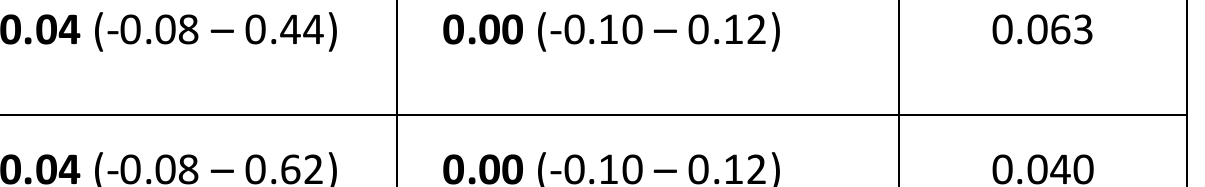

OCR this image section by section, from top to bottom, and left to right.
----------
[assistant]: 0.04 (-0.08 – 0.44) 0.00 (-0.10 – 0.12) 0.063
0.04 (-0.08 – 0.62) 0.00 (-0.10 – 0.12) 0.040

----------


In [235]:
def decode_base64_image(base64_string):
    # 解码base64字符串并返回PIL图像对象
    image_data = base64.b64decode(base64_string)
    image = Image.open(BytesIO(image_data))
    return image

def format_messages(messages, images):
    for msg in messages:
        msg_content = f"[{msg['role']}]: "
        if isinstance(msg["content"], str):
            msg_content += msg["content"]
            continue
        for content in msg["content"]:
            if content["type"] == "image":
                if msg_content != "":
                    print(msg_content)
                    msg_content = ""
                name = content["image"]
                image = images[name]
                display(name, image.size, image)
            elif content["type"] == "text":
                msg_content += content["text"]
            elif content["type"] == "video":
                print(content)
        if msg_content != "":
            print(msg_content)
        print("-" * 10)

def format_segments(segments, images):
    for seg in segments:
        if seg["type"] == "text":
            print(seg["text"] + "\n")
        elif seg["type"] == "image":
            name = seg["image"]
            image = images[name]
            display(name, image.size, image)
            

def display_sample(sample):
    source = sample['source']
    images = json.loads(sample.pop('images'))
    messages = None if sample['messages'] is None else json.loads(sample['messages'])
    segments = None if sample['segments'] is None else json.loads(sample['segments'])
    for name, base64_string in images.items():
        image = decode_base64_image(base64_string)
        images[name] = image

    print(f"source={source}, img_nums={len(images)}, messages={messages}, segments={segments}")
    if segments is not None:
        print("segments sample. Content:")
        print(sample['segments'])
        print("=" * 10)
        format_segments(segments, images)
    elif messages is not None:
        print("message sample. Content:")
        print(sample['messages'])
        print("=" * 10)
        format_messages(messages, images)

display_sample(df.sample().iloc[0].to_dict())

In [ ]:
df